# Validate SMOS-IC -> M36 Remapping

Small QC notebook for the cached outputs produced by:

- `projects/SMOS_IC/scripts/preprocess_smos_ic_daily_to_m36.py`

Checks included:

1. Manifest sanity / coverage diagnostics.
2. Conservation-style check: compare source-domain weighted mean vs remapped weighted mean.
3. Quick visual spot-check for one day.


In [1]:
from pathlib import Path
import re
import sys
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from netCDF4 import Dataset

plt.rcParams['figure.dpi'] = 120

# Resolve repo root robustly
REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / 'projects').exists():
    for p in REPO_ROOT.parents:
        if (p / 'projects').exists():
            REPO_ROOT = p
            break

SMOS_ROOT = Path('/Users/amfox/Desktop/SMOS_IC')
CACHE_DIR = REPO_ROOT / 'projects/SMOS_IC/output/preprocessed_m36_daily'
MANIFEST = CACHE_DIR / 'smos_ic_m36_daily_manifest.csv'
MAPPING = CACHE_DIR / 'smos25km_to_m36_conservative_mapping.npz'

# QC / masking settings used by preprocessing script
SCENE_FLAG_MAX = 1
TB_RMSE_MAX = 8.0
SM_MIN = 0.0
SM_MAX = 1.0
MIN_COVERAGE_FRAC = 0.05

# Runtime controls for this notebook
MAX_DATES_TO_CHECK = 120      # keep this small for quick tests
VISUAL_DATE = None            # e.g. '20220311' or None -> middle checked date

print('REPO_ROOT:', REPO_ROOT)
print('SMOS_ROOT:', SMOS_ROOT)
print('CACHE_DIR :', CACHE_DIR)

for p in [SMOS_ROOT, MANIFEST, MAPPING]:
    if not Path(p).exists():
        raise FileNotFoundError(f'Missing required path: {p}')


REPO_ROOT: /Users/amfox/Desktop/geosldas-analysis
SMOS_ROOT: /Users/amfox/Desktop/SMOS_IC
CACHE_DIR : /Users/amfox/Desktop/geosldas-analysis/projects/SMOS_IC/output/preprocessed_m36_daily


In [2]:
DATE_RE = re.compile(r'_(20\d{6})T')


def parse_date_from_name(name: str):
    m = DATE_RE.search(name)
    if not m:
        return None
    return datetime.strptime(m.group(1), '%Y%m%d').date()


def build_file_index(root: Path):
    asc_dirs = [
        root / 'SMOS_IC_V2_ASC_2018_2021',
        root / 'SMOS_IC_V2_ASC',
    ]
    des_dirs = [
        root / 'SMOS_IC_V2_DES_2018_2021',
        root / 'SMOS_IC_OPER_DES',
    ]
    asc = {}
    des = {}

    for d in asc_dirs:
        if not d.exists():
            continue
        for f in sorted(d.glob('*.nc')):
            dt = parse_date_from_name(f.name)
            if dt is not None:
                asc[dt] = f

    for d in des_dirs:
        if not d.exists():
            continue
        for f in sorted(d.glob('*.nc')):
            dt = parse_date_from_name(f.name)
            if dt is not None:
                des[dt] = f

    return asc, des


def read_qc_smos(path: Path, scene_flag_max=SCENE_FLAG_MAX, tb_rmse_max=TB_RMSE_MAX, sm_min=SM_MIN, sm_max=SM_MAX):
    with Dataset(path, 'r') as ds:
        sm = ds.variables['Soil_Moisture'][:]
        sf = ds.variables['Scene_Flags'][:]
        rmse = ds.variables['RMSE'][:]

    if np.ma.isMaskedArray(sm):
        sm = sm.filled(np.nan)
    if np.ma.isMaskedArray(sf):
        sf = sf.filled(np.nan)
    if np.ma.isMaskedArray(rmse):
        rmse = rmse.filled(np.nan)

    sm = np.asarray(sm, dtype=float)
    sf = np.asarray(sf, dtype=float)
    rmse = np.asarray(rmse, dtype=float)

    good = (
        np.isfinite(sm)
        & np.isfinite(sf)
        & np.isfinite(rmse)
        & (sf <= float(scene_flag_max))
        & (rmse <= float(tb_rmse_max))
        & (sm >= float(sm_min))
        & (sm <= float(sm_max))
    )

    out = np.full(sm.shape, np.nan, dtype=float)
    out[good] = sm[good]
    return out


def merge_asc_des(sm_asc, sm_des):
    if sm_asc is None and sm_des is None:
        return None
    if sm_asc is None:
        return sm_des
    if sm_des is None:
        return sm_asc

    fa = np.isfinite(sm_asc)
    fd = np.isfinite(sm_des)
    out = np.full(sm_asc.shape, np.nan, dtype=float)
    both = fa & fd
    out[both] = 0.5 * (sm_asc[both] + sm_des[both])
    out[fa & ~fd] = sm_asc[fa & ~fd]
    out[~fa & fd] = sm_des[~fa & fd]
    return out


In [3]:
manifest = pd.read_csv(MANIFEST, dtype={'date': str})
manifest = manifest.sort_values('date').reset_index(drop=True)
manifest['date_dt'] = pd.to_datetime(manifest['date'], format='%Y%m%d', errors='coerce')

mapping_raw = np.load(MAPPING)
mapping = {k: mapping_raw[k] for k in mapping_raw.files}
mapping_raw.close()

print('Manifest rows:', len(manifest))
print('Date range   :', manifest['date'].iloc[0], '->', manifest['date'].iloc[-1])
print('Mapping entries (sparse overlaps):', mapping['map_tgt'].size)
print('Target cells in mapping          :', int(mapping['n_tgt']))
print('Source grid shape                :', int(mapping['src_nlat']), int(mapping['src_nlon']))

target_area = float(mapping['target_cell_area'])


Manifest rows: 2148
Date range   : 20180801 -> 20240630
Mapping entries (sparse overlaps): 670222
Target cells in mapping          : 112573
Source grid shape                : 584 1388


n_valid_m36 summary:
count     2148.000000
mean     10868.713687
std        808.538710
min       1792.000000
5%        9585.750000
50%      10922.000000
95%      11978.600000
max      12764.000000
Name: n_valid_m36, dtype: float64
mean_coverage_m36 summary:
count    2148.000000
mean        0.822681
std         0.018478
min         0.738487
5%          0.790293
50%         0.823385
95%         0.851784
max         0.871258
Name: mean_coverage_m36, dtype: float64


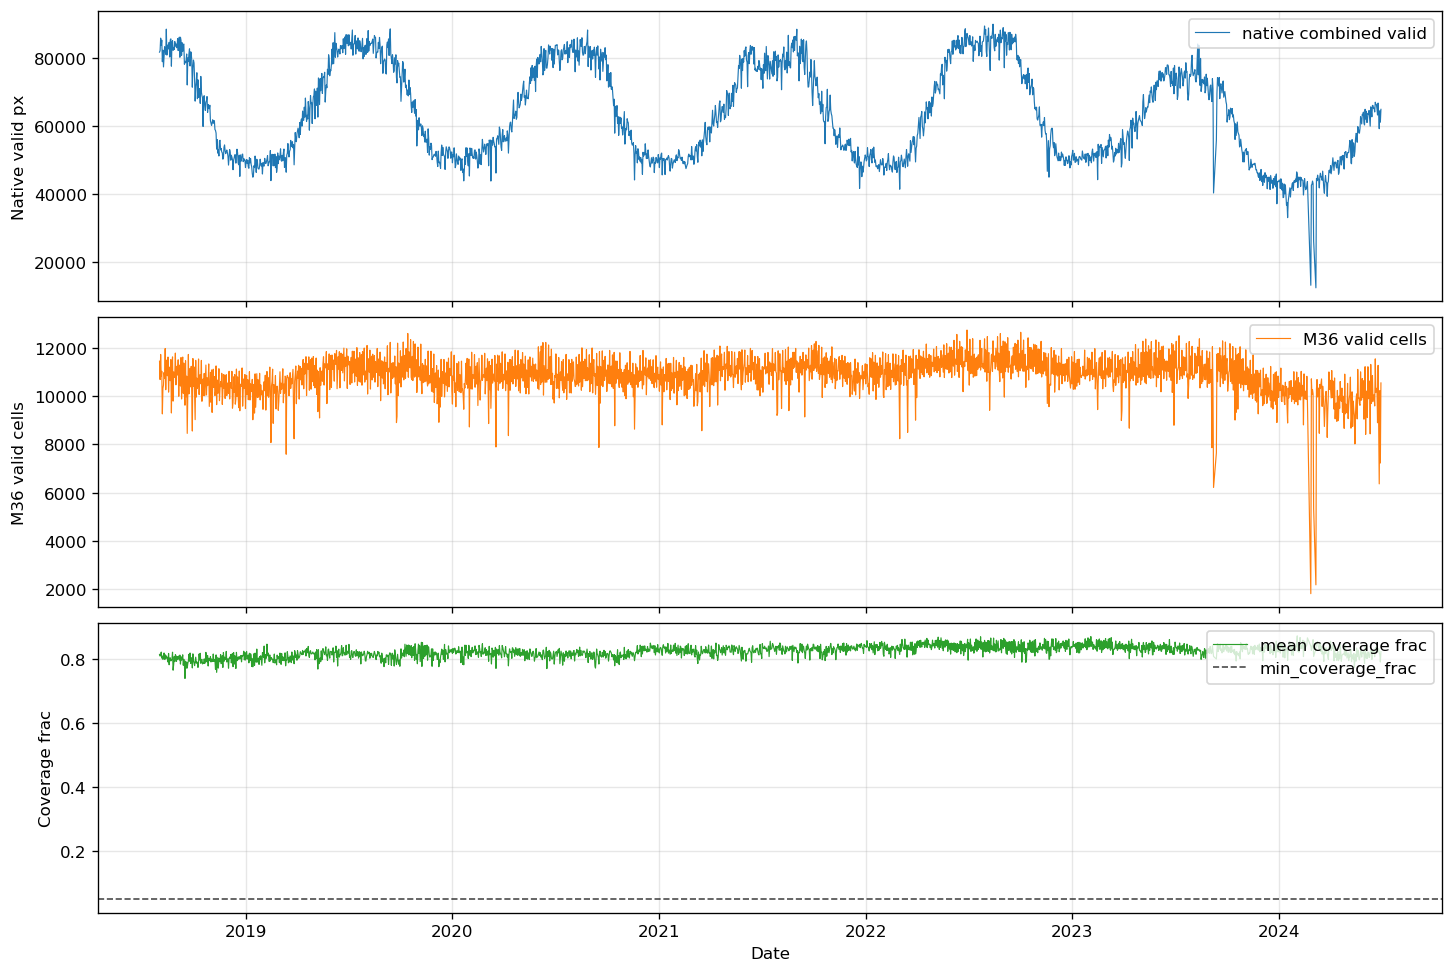

In [4]:
# 1) Manifest sanity + coverage diagnostics
for c in ['n_valid_asc_native','n_valid_des_native','n_valid_combined_native','n_valid_m36','mean_coverage_m36']:
    if c in manifest.columns:
        manifest[c] = pd.to_numeric(manifest[c], errors='coerce')

print('n_valid_m36 summary:')
print(manifest['n_valid_m36'].describe(percentiles=[0.05,0.5,0.95]))
print('mean_coverage_m36 summary:')
print(manifest['mean_coverage_m36'].describe(percentiles=[0.05,0.5,0.95]))

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True, constrained_layout=True)

axes[0].plot(manifest['date_dt'], manifest['n_valid_combined_native'], lw=0.7, label='native combined valid')
axes[0].set_ylabel('Native valid px')
axes[0].grid(alpha=0.3)
axes[0].legend(loc='upper right')

axes[1].plot(manifest['date_dt'], manifest['n_valid_m36'], lw=0.7, color='tab:orange', label='M36 valid cells')
axes[1].set_ylabel('M36 valid cells')
axes[1].grid(alpha=0.3)
axes[1].legend(loc='upper right')

axes[2].plot(manifest['date_dt'], manifest['mean_coverage_m36'], lw=0.7, color='tab:green', label='mean coverage frac')
axes[2].axhline(MIN_COVERAGE_FRAC, ls='--', lw=1.0, color='k', alpha=0.7, label='min_coverage_frac')
axes[2].set_ylabel('Coverage frac')
axes[2].set_xlabel('Date')
axes[2].grid(alpha=0.3)
axes[2].legend(loc='upper right')

plt.show()


Checked dates: 120
Delta stats (output - source):
count    1.200000e+02
mean    -9.162469e-12
std      4.635339e-11
min     -1.236999e-10
5%      -8.665267e-11
50%     -8.651566e-12
95%      7.041639e-11
max      1.071087e-10
Name: delta_output_minus_source, dtype: float64


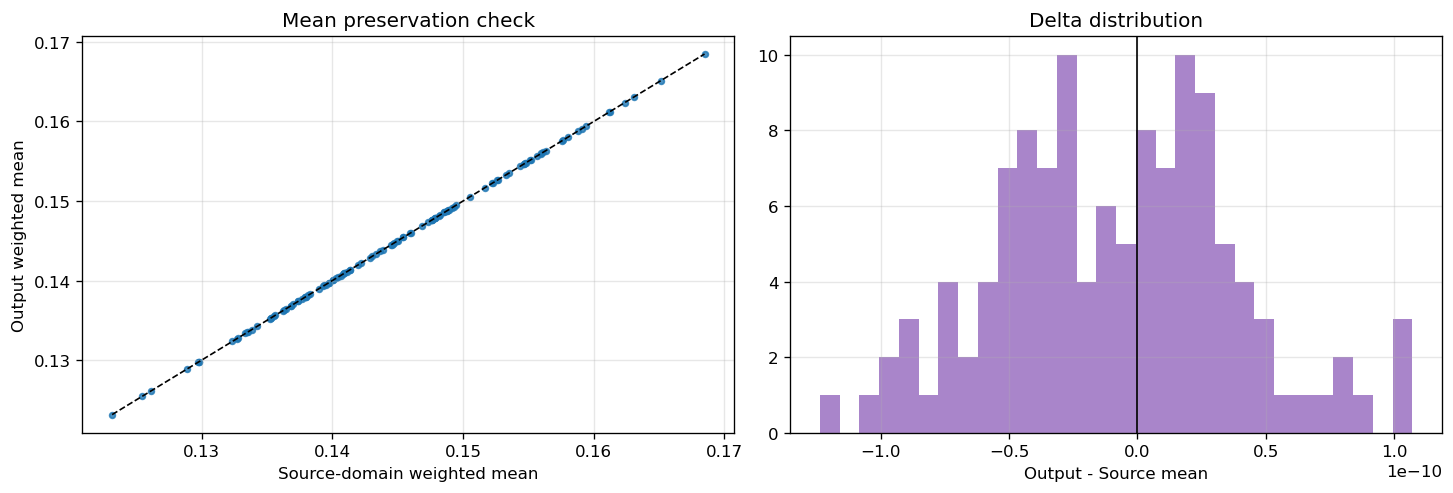

,date,mean_source_domain,mean_output_domain,delta_output_minus_source,n_cells_output
0,20180801,0.147313,0.147313,1.055306e-11,11467
1,20180819,0.138320,0.138320,-6.418202e-11,11221
2,20180906,0.137378,0.137378,8.002321e-12,11309
3,20180924,0.129774,0.129774,2.600309e-11,11163
4,20181012,0.132673,0.132673,-9.345136e-12,10911


In [5]:
# 2) Conservation-style mean check over sampled dates
asc_idx, des_idx = build_file_index(SMOS_ROOT)

map_tgt = mapping['map_tgt'].astype(np.int64)
map_src = mapping['map_src'].astype(np.int64)
map_area = mapping['map_area'].astype(float)
n_tgt = int(mapping['n_tgt'])

# choose sample dates for a quick run
all_dates = manifest['date'].dropna().astype(str).tolist()
if len(all_dates) > MAX_DATES_TO_CHECK:
    idx = np.linspace(0, len(all_dates)-1, MAX_DATES_TO_CHECK).round().astype(int)
    check_dates = [all_dates[i] for i in idx]
else:
    check_dates = all_dates

rows = []
for tag in check_dates:
    d = datetime.strptime(tag, '%Y%m%d').date()

    sm_asc = read_qc_smos(asc_idx[d]) if d in asc_idx else None
    sm_des = read_qc_smos(des_idx[d]) if d in des_idx else None
    sm_comb = merge_asc_des(sm_asc, sm_des)
    if sm_comb is None:
        continue

    src_flat = sm_comb.ravel(order='C')
    vals = src_flat[map_src]
    good = np.isfinite(vals)

    num_t = np.bincount(map_tgt[good], weights=map_area[good] * vals[good], minlength=n_tgt)
    den_t = np.bincount(map_tgt[good], weights=map_area[good], minlength=n_tgt)

    keep = den_t > (MIN_COVERAGE_FRAC * target_area)
    if not np.any(keep):
        continue

    mean_from_source = num_t[keep].sum() / den_t[keep].sum()

    out_nc = CACHE_DIR / f'smos_ic_sm_m36_{tag}.nc'
    if not out_nc.exists():
        continue
    with Dataset(str(out_nc), 'r') as ds:
        sm_obs = np.asarray(ds.variables['sm_obs'][:], dtype=float)
        cov = np.asarray(ds.variables['coverage_frac'][:], dtype=float)

    ok_out = np.isfinite(sm_obs) & np.isfinite(cov) & (cov > 0)
    if not np.any(ok_out):
        continue

    mean_from_output = np.sum(sm_obs[ok_out] * cov[ok_out]) / np.sum(cov[ok_out])

    rows.append({
        'date': tag,
        'mean_source_domain': mean_from_source,
        'mean_output_domain': mean_from_output,
        'delta_output_minus_source': mean_from_output - mean_from_source,
        'n_cells_output': int(ok_out.sum()),
    })

check_df = pd.DataFrame(rows)
print('Checked dates:', len(check_df))
if len(check_df) == 0:
    raise RuntimeError('No dates checked. Verify inputs and cache paths.')

print('Delta stats (output - source):')
print(check_df['delta_output_minus_source'].describe(percentiles=[0.05, 0.5, 0.95]))

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

axes[0].scatter(check_df['mean_source_domain'], check_df['mean_output_domain'], s=12, alpha=0.8)
mn = min(check_df['mean_source_domain'].min(), check_df['mean_output_domain'].min())
mx = max(check_df['mean_source_domain'].max(), check_df['mean_output_domain'].max())
axes[0].plot([mn, mx], [mn, mx], 'k--', lw=1)
axes[0].set_xlabel('Source-domain weighted mean')
axes[0].set_ylabel('Output weighted mean')
axes[0].set_title('Mean preservation check')
axes[0].grid(alpha=0.3)

axes[1].hist(check_df['delta_output_minus_source'], bins=30, color='tab:purple', alpha=0.8)
axes[1].axvline(0, color='k', lw=1)
axes[1].set_xlabel('Output - Source mean')
axes[1].set_title('Delta distribution')
axes[1].grid(alpha=0.3)

plt.show()

check_df.head()


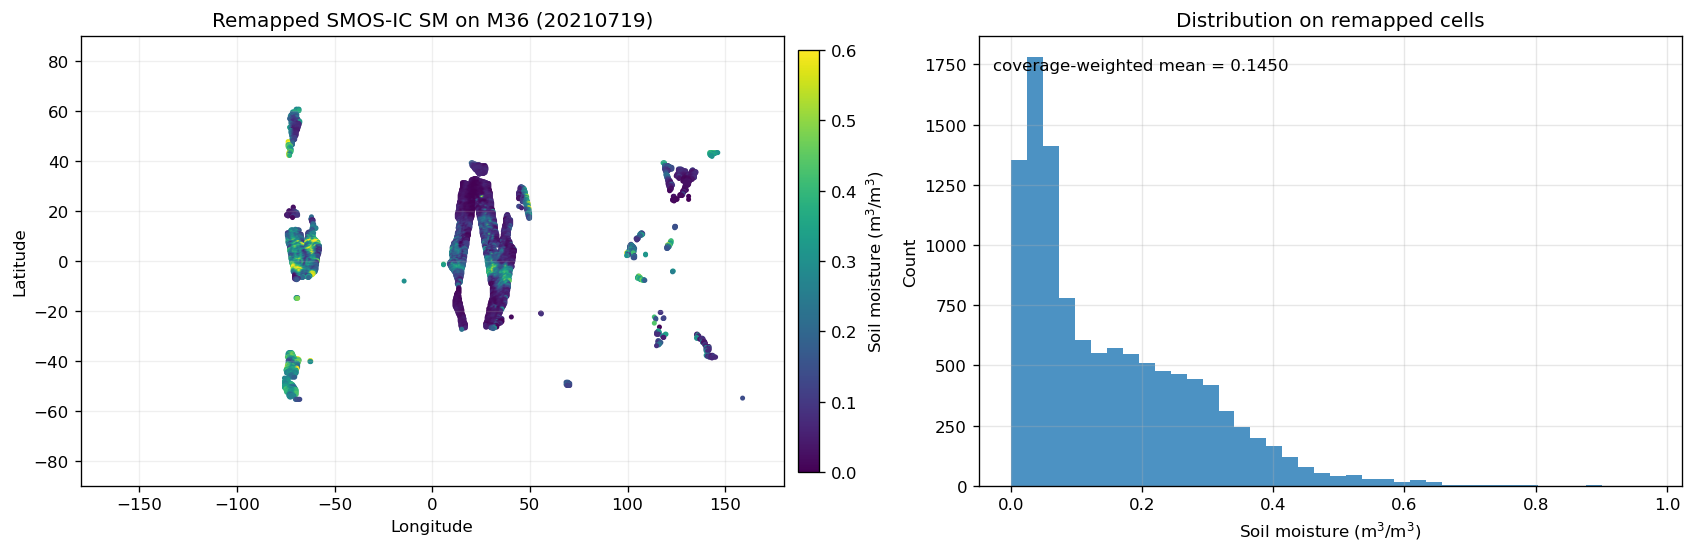

In [6]:
# 3) Visual spot check for one date (quick map + histogram)
lin = mapping['m36_linear'].astype(np.int64)
rep_lat = mapping['rep_lat'].astype(float)
rep_lon = mapping['rep_lon'].astype(float)

# Build lookup from linear index to representative lat/lon
sort_idx = np.argsort(lin)
lin_sorted = lin[sort_idx]
lat_sorted = rep_lat[sort_idx]
lon_sorted = rep_lon[sort_idx]

if VISUAL_DATE is None:
    VISUAL_DATE = check_df['date'].iloc[len(check_df)//2]

with Dataset(str(CACHE_DIR / f'smos_ic_sm_m36_{VISUAL_DATE}.nc'), 'r') as ds:
    idx = np.asarray(ds.variables['idx_EASEv2_lonxlat'][:], dtype=np.int64)
    sm = np.asarray(ds.variables['sm_obs'][:], dtype=float)
    cov = np.asarray(ds.variables['coverage_frac'][:], dtype=float)

loc = np.searchsorted(lin_sorted, idx)
if np.any(loc >= lin_sorted.size) or np.any(lin_sorted[loc] != idx):
    raise RuntimeError('Index lookup mismatch in mapping cache.')

lat = lat_sorted[loc]
lon = lon_sorted[loc]

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), constrained_layout=True)

sc = axes[0].scatter(lon, lat, c=sm, s=4, cmap='viridis', vmin=0, vmax=0.6)
axes[0].set_xlim(-180, 180)
axes[0].set_ylim(-90, 90)
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
axes[0].set_title(f'Remapped SMOS-IC SM on M36 ({VISUAL_DATE})')
axes[0].grid(alpha=0.2)
cb = plt.colorbar(sc, ax=axes[0], fraction=0.03, pad=0.02)
cb.set_label('Soil moisture (m$^3$/m$^3$)')

axes[1].hist(sm[np.isfinite(sm)], bins=40, alpha=0.8, label='remapped SM')
axes[1].set_xlabel('Soil moisture (m$^3$/m$^3$)')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution on remapped cells')
axes[1].grid(alpha=0.3)

# coverage-weighted mean annotation
ok = np.isfinite(sm) & np.isfinite(cov) & (cov > 0)
if np.any(ok):
    m = np.sum(sm[ok] * cov[ok]) / np.sum(cov[ok])
    axes[1].text(0.02, 0.95, f'coverage-weighted mean = {m:.4f}',
                 transform=axes[1].transAxes, va='top', ha='left')

plt.show()


## Interpreting results quickly

- If `delta_output_minus_source` stays near 0 (tight histogram), remap is behaving conservatively.
- If there are outlier dates, inspect those dates in the manifest and raw file availability/QC counts.
- If map looks shifted/rotated, stop and inspect source grid geometry assumptions before using in analysis.
